# Evaluation of the LSTMKraus model

Compares the model's conditional state $\rho_\text{NN}(t)$ to the ground-truth
SME trajectory $\rho_\text{true}(t)$ and extracts the underlying physics.
Plots 3–5 are restricted to the $\hat\sigma_z$ measurement basis; plots 2, 6–7 use
all three bases. All uncertainty bands/bars are **bootstrap $(\mu\pm1\sigma)$**.

Each plot is split into a **computation** cell and a **plotting** cell, so the
figures can be restyled without re-running the model or the fits.

1. Per-trajectory $\rho$ vs $\rho_\text{true}$ with the SME($\hat\theta$) fit.
2. Full-state Uhlmann fidelity $\mathrm{F}(\rho_\text{NN},\rho_\text{true})$ vs time, per measurement direction.
3. Parameter residuals $\hat\theta-\theta_\text{true}$ vs $\Omega$.
4. Distribution of $P_\text{end}$ (the BCE training target): predicted vs SME-true histograms, varying- and fixed-$\Omega$.
5. Physical validity of $\rho_\text{NN}$ (trace, Hermiticity, positivity).
6. Unconditional dynamics: ensemble-mean $\langle\hat\sigma\rangle$ vs Lindblad, per basis.
7. Per-trajectory $\rho$-elements in the z-basis for each measurement direction.

In [2]:
import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]
import numpy as np
import torch
import matplotlib.pyplot as plt

from constants import *
from help_functions import *
import plot_style as ps

rng = np.random.default_rng(0)

## Setup — load data and trained models

In [3]:
N_eval = 10000
N_BOOT = 1000   # bootstrap resamples for every uncertainty estimate (95% CI)

data_vary,  model_vary  = load_dataset_and_model('_vary',  N_eval)
data_const, model_const = load_dataset_and_model('_const', N_eval)

THETA_RATES_TRUE = np.array([KAPPA, ETA, GAMMA_DECAY])
PARAM_NAMES = [r'$\Omega$', r'$\kappa$', r'$\eta$', r'$\gamma_{decay}$']
TASK_Z, TASK_X, TASK_Y = 0, 1, 2
TASK_NAMES = {0: r'$\hat\sigma_z$', 1: r'$\hat\sigma_x$', 2: r'$\hat\sigma_y$'}
t_axis = times[1:]

print(f'vary  loaded: {len(data_vary["J_eval"])} trajectories')
print(f'const loaded: {len(data_const["J_eval"])} trajectories')

vary  loaded: 30000 trajectories
const loaded: 30000 trajectories


## Shared computation — forward every trajectory once
Runs the model on both datasets and caches $\rho_\text{NN}$, $\rho_\text{true}$. Also possibly does the fidelity computation.

In [4]:
# The full-state Uhlmann fidelity ('qfidelity') is the slow part of evaluate_dataset.
# Only Plot 2 needs it, so this is False by default -- the cache then builds fast
# (enough for Plots 4, 6, 7). Set it to True and re-run this cell before Plot 2.
COMPUTE_QFIDELITY = False

eval_cache = {
    'vary':  evaluate_dataset(model_vary,  data_vary,  compute_qfidelity=COMPUTE_QFIDELITY),
    'const': evaluate_dataset(model_const, data_const, compute_qfidelity=COMPUTE_QFIDELITY),
}

## Plot 1 — Per-trajectory $\rho$ vs $\rho_\text{true}$ with SME($\hat\theta$) fit
The fit matches the SME to $\rho_{00}$ only ($\hat\theta$ is tied to
$\rho_\text{NN}$, not $\rho_\text{true}$), so the SME($\hat\theta$) curve is
drawn **only on $\rho_{00}$ panels**.

* **Varying-$\Omega$**: three trajectories (low / medium / high $\Omega$), each
  showing $\rho_{00}$, stacked on a shared time axis.
* **Fixed-$\Omega$**: one trajectory, all four components stacked in a single
  column on a shared time axis.

In [ ]:
PLOT1_TASK = TASK_Z

z_indices = (data_vary['task_eval'] == PLOT1_TASK).nonzero(as_tuple=True)[0].numpy()
z_omegas  = data_vary['omegas_eval'][z_indices].numpy()
by_omega  = np.argsort(z_omegas)
selection = [('Low', by_omega[0]), ('Medium', by_omega[len(by_omega)//2]), ('High', by_omega[-1])] #selects 3 Omegas

vary_fits = []
for label, rank in selection: #selects the 3 trajectories corresponding to the 3 Omegas picked and performs the fit
    traj_index = int(z_indices[rank])
    fit = fit_trajectory(model_vary, data_vary, traj_index,
                         float(data_vary['omegas_eval'][traj_index]), THETA_RATES_TRUE, dt)
    fit['label'] = label
    vary_fits.append(fit)

const_index = int((data_const['task_eval'] == PLOT1_TASK).nonzero(as_tuple=True)[0][0])
const_fit   = fit_trajectory(model_const, data_const, const_index,
                             float(data_const['omegas_eval'][const_index]), THETA_RATES_TRUE, dt)
const_fit['label'] = 'Fixed'

python(34882) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


theta_hat / theta_true:
  Low     Omega  5.241/4.021   kappa 0.756/0.400   eta 0.170/0.300   gamma_d 0.560/0.100
  Medium  Omega  5.157/5.028   kappa 1.022/0.400   eta 0.143/0.300   gamma_d 0.472/0.100
  High    Omega  5.192/6.031   kappa 0.934/0.400   eta 0.144/0.300   gamma_d 0.476/0.100
  Fixed   Omega  4.950/5.027   kappa 0.289/0.400   eta 0.307/0.300   gamma_d 0.334/0.100


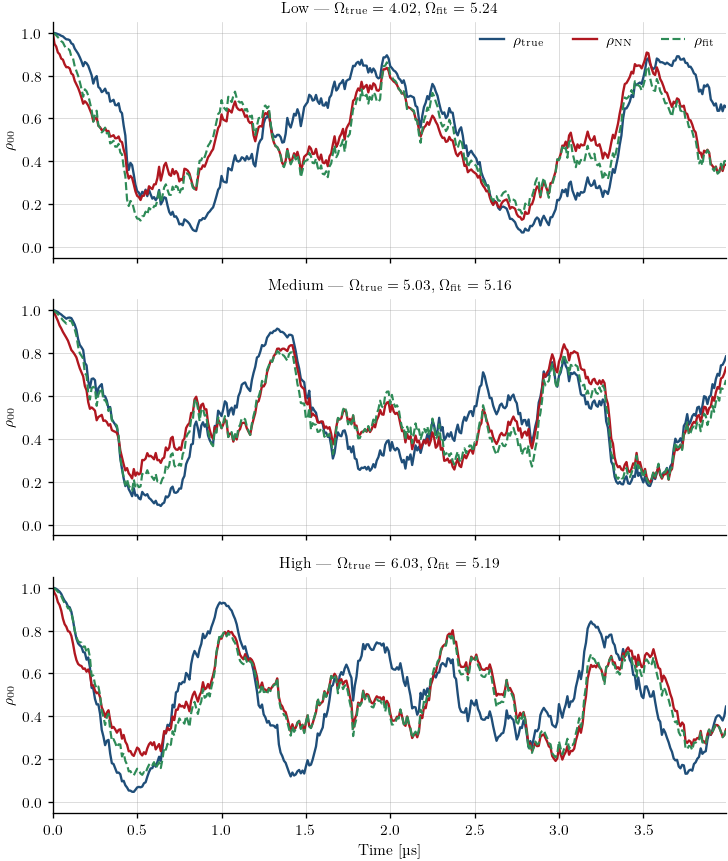

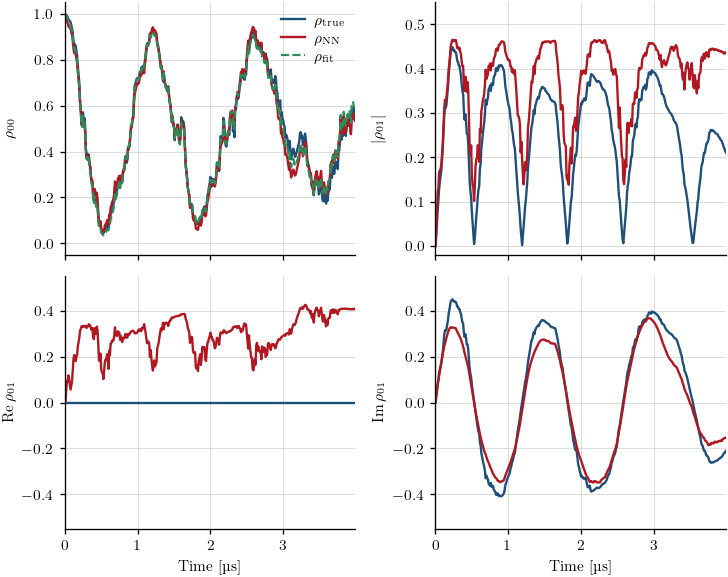

In [6]:
# Varying-Omega: rho_00 only, one row per trajectory on a shared time axis.
label, extract, ylim = RHO_COMPONENTS[0]
fig, axes = plt.subplots(len(vary_fits), 1, sharex=True, figsize=ps.figsize(aspect=0.85))
for ax, fit in zip(axes, vary_fits):
    draw_component(ax, fit, extract, ylim, show_fit=True)
    ax.set_ylabel(label)
    ax.set_title(rf"{fit['label']} {ps.EMDASH} "
                 rf"$\Omega_\text{{true}} = {fit['theta_true'][0]:.2f}$, "
                 rf"$\Omega_\text{{fit}} = {fit['theta_hat'][0]:.2f}$")
axes[0].legend(loc='upper right', ncol=3)
axes[-1].set_xlabel(r'Time [µs]')
fig.align_ylabels(axes)
fig.tight_layout()
ps.save_fig(fig, 'rho00_varying')

# Fixed-Omega: all four components in a 2x2 grid (fit drawn only on rho_00).
fig, axes = plt.subplots(2, 2, sharex=True, figsize=ps.figsize(aspect=1.25))
for ax, (label, extract, ylim) in zip(axes.flat, RHO_COMPONENTS):
    draw_component(ax, const_fit, extract, ylim, show_fit=(label == RHO_COMPONENTS[0][0]))
    ax.set_ylabel(label)
axes[0, 0].legend(loc='best')
for ax in axes[-1]:
    ax.set_xlabel(r'Time [µs]')
fig.align_ylabels(axes)
fig.tight_layout()
ps.save_fig(fig, 'rho_fixed')

print('theta_hat / theta_true:')
for fit in vary_fits:
    print_theta(fit['label'], fit)
print_theta('Fixed', const_fit)

## Plot 2 — Full-state fidelity $\mathrm{F}(\rho_\text{NN}, \rho_\text{true})$ vs time, per measurement direction
We compare the entire
conditional density matrix via the Uhlmann fidelity
$$\mathrm{F}(\rho_\text{NN},\rho_\text{true})=\mathrm{Tr}\sqrt{\sqrt{\rho_\text{NN}}\,\rho_\text{true}\,\sqrt{\rho_\text{NN}}}\,.$$
One panel per measurement direction ($\hat C_\text{mon}\propto\hat\sigma_z,
\hat\sigma_x,\hat\sigma_y$) lets the three bases be compared directly, with
varying- and fixed-$\Omega$ overlaid in each panel. The band is the bootstrap
$(\mu\pm1\sigma)$ (resampling trajectories at each time step).

> **Requires `qfidelity`.** Set `COMPUTE_QFIDELITY = True` in the shared-computation cell, otherwise the cell below will return an error.

In [7]:
PLOT2_TASKS = (TASK_Z, TASK_X, TASK_Y)
fidelity_bands = {name: {task: quantum_fidelity_band(cache, N_BOOT, rng, task)
                         for task in PLOT2_TASKS}
                  for name, cache in eval_cache.items()}

ValueError: qfidelity was not computed -- rebuild eval_cache with compute_qfidelity=True (COMPUTE_QFIDELITY = True).

NameError: name 'fidelity_bands' is not defined

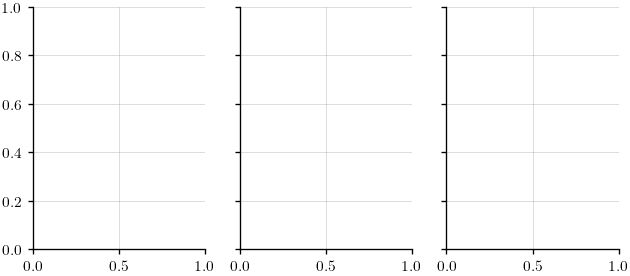

In [8]:
dataset_style = {
    'vary':  (ps.PALETTE['purple'], '-',  r'Varying $\Omega$'),
    'const': (ps.PALETTE['ochre'],  '--', r'Fixed $\Omega$'),
}

fig, axes = plt.subplots(1, 3, sharey=True, figsize=ps.figsize(ps.FULLWIDTH_IN, aspect=2.4))
for ax, task in zip(axes, PLOT2_TASKS):
    for name, color_ls_label in dataset_style.items():
        color, ls, label = color_ls_label
        band = fidelity_bands[name][task]
        ax.plot(t_axis, band['mean'], color=color, ls=ls, label=label)
        ax.fill_between(t_axis, band['lo'], band['hi'], color=color, alpha=0.25)
    ax.set_title(rf'$\hat C_\text{{mon}}\propto\hat\sigma_{TASK_BASIS_CHAR[task]}$')
    ax.set_xlabel(r'Time [µs]')

axes[0].set_ylabel(r'$\mathrm{F}(\rho_\text{NN}, \rho_\text{true})$')
axes[0].legend(loc='best')
fig.tight_layout()
ps.save_fig(fig, 'fidelity_bases')

for name, by_task in fidelity_bands.items():
    summary = '   '.join(f'{TASK_NAMES[task]} F = {by_task[task]["mean"].mean():.4f}'
                         for task in PLOT2_TASKS)
    print(f'[{name}] time-averaged  {summary}')

## Plot 3 — Parameter residuals $\hat\theta-\theta_\text{true}$ vs $\Omega$ ($\hat C_\text{mon}\propto\hat\sigma_z$)
Trajectory-matching fit of $(\Omega,\kappa,\eta,\gamma_d)$ on a strided
subset, residuals binned by true $\Omega$. Error bars are a bootstrap
$(\mu\pm1\sigma)$ of the mean residual (resampling trajectories). A bin needs more than one
trajectory for a CI, so bins with fewer than `MIN_PER_BIN` are omitted — lower
`STRIDE` or `N_BINS` to populate them rather than padding empty bins. The
true values of $\kappa,\eta,\gamma_d$ are printed in each subplot's title;
the legend lists how many trajectories went into each dataset's fit.

In [13]:
STRIDE, MAXITER = 30, 40

residuals_vary  = fit_residuals(model_vary,  data_vary,  STRIDE, MAXITER, THETA_RATES_TRUE, dt)
residuals_const = fit_residuals(model_const, data_const, STRIDE, MAXITER, THETA_RATES_TRUE, dt)

Plot 3 sample sizes:  varying Omega N=334   fixed Omega N=334
[vary] residual bias +/- std  (N=334):
    Omega    +0.1650 +/- 0.6371
    kappa    +0.3771 +/- 0.3065
    eta      -0.0946 +/- 0.1304
    gamma_d  +0.4719 +/- 0.2301
[const] residual bias +/- std  (N=334):
    Omega    -0.1133 +/- 0.0984
    kappa    -0.0511 +/- 0.1309
    eta      +0.0722 +/- 0.1854
    gamma_d  +0.3764 +/- 0.1655


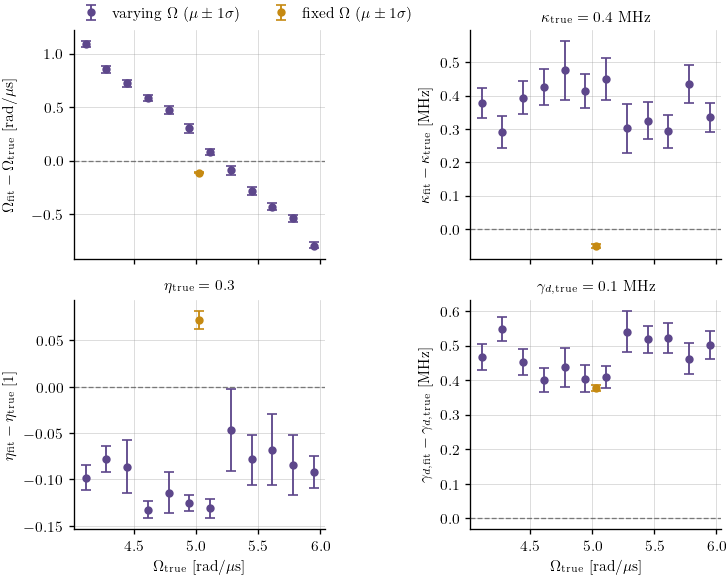

In [ ]:
N_BINS = 12
MIN_PER_BIN = 2   # a bootstrap CI is undefined for a single trajectory

# Note: rates (kappa, gamma_d) use MHz; Omega is an angular frequency so it stays in rad/µs.

RESIDUAL_LABELS = [
    r'$\Omega_\text{fit} - \Omega_\text{true}\ [\mathrm{rad}/\mu\mathrm{s}]$',
    r'$\kappa_\text{fit} - \kappa_\text{true}\ [\mathrm{MHz}]$',
    r'$\eta_\text{fit} - \eta_\text{true}\ [1]$',
    r'$\gamma_{d,\text{fit}} - \gamma_{d,\text{true}}\ [\mathrm{MHz}]$',
]
PANEL_TITLES = [
    None,
    rf'$\kappa_\text{{true}} = {KAPPA:g}\ \mathrm{{MHz}}$',
    rf'$\eta_\text{{true}} = {ETA:g}$',
    rf'$\gamma_{{d,\text{{true}}}} = {GAMMA_DECAY:g}\ \mathrm{{MHz}}$',
]

#residual values and omegas are unpacked
residuals, omegas = residuals_vary
N_vary  = len(residuals)
bin_edges    = np.linspace(omegas.min(), omegas.max(), N_BINS + 1)
vary_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_of_traj  = np.clip(np.digitize(omegas, bin_edges) - 1, 0, N_BINS - 1)
vary_mean = np.full((N_BINS, 4), np.nan)
vary_lo   = np.full((N_BINS, 4), np.nan)
vary_hi   = np.full((N_BINS, 4), np.nan)
for b in range(N_BINS):
    in_bin = bin_of_traj == b
    if in_bin.sum() >= MIN_PER_BIN:
        vary_mean[b], vary_lo[b], vary_hi[b] = bootstrap_mean_ci(residuals[in_bin], N_BOOT, rng)

const_residuals, const_omegas  = residuals_const
N_const = len(const_residuals)
const_mean, const_lo, const_hi = bootstrap_mean_ci(const_residuals, N_BOOT, rng)
const_omega = const_omegas.mean()

print(f'Plot 3 sample sizes:  varying Omega N={N_vary}   fixed Omega N={N_const}')

fig, axes = plt.subplots(2, 2, sharex=True, figsize=ps.figsize(aspect=1.25))
axes_flat = axes.ravel()
for k in range(4):
    ax = axes_flat[k]
    ax.axhline(0, color=ps.PALETTE['gray'], ls='--', lw=0.8, alpha=0.7)

    ax.errorbar(vary_centers, vary_mean[:, k],
                yerr=[vary_mean[:, k] - vary_lo[:, k], vary_hi[:, k] - vary_mean[:, k]],
                color=ps.PALETTE['purple'], capsize=3, marker='o', ms=4, ls='none',
                label=r'varying $\Omega$ ($\mu\pm1\sigma$)')

    ax.errorbar([const_omega], [const_mean[k]],
                yerr=[[const_mean[k] - const_lo[k]], [const_hi[k] - const_mean[k]]],
                color=ps.PALETTE['ochre'], capsize=3, marker='o', ms=4, ls='none',
                label=r'fixed $\Omega$ ($\mu\pm1\sigma$)')

    ax.set_ylabel(RESIDUAL_LABELS[k])
    if PANEL_TITLES[k] is not None:
        ax.set_title(PANEL_TITLES[k])

axes[0, 0].legend(loc='lower left', bbox_to_anchor=(0.0, 1.02),
                  ncol=2, borderaxespad=0.0, frameon=False)
for ax in axes[-1]:
    ax.set_xlabel(r'$\Omega_\text{true}\ [\mathrm{rad}/\mu\mathrm{s}]$')
fig.align_ylabels(axes)
fig.tight_layout()
ps.save_fig(fig, 'param_residuals')

for tag, (residuals, _) in [('vary', residuals_vary), ('const', residuals_const)]:
    print(f'[{tag}] residual bias +/- std  (N={len(residuals)}):')
    for k, name in enumerate(['Omega', 'kappa', 'eta', 'gamma_d']):
        print(f'    {name:8s} {residuals[:, k].mean():+.4f} +/- {residuals[:, k].std(ddof=1):.4f}')

## Plot 4 — Distribution of $P_\text{end}$ ($\hat C_\text{mon}\propto\hat\sigma_z$)
Prediction histograms of the model's end-probability $P_\text{end}^\text{NN}$ overlaid on the
SME-true distribution, with the varying-$\Omega$ model (left) next to the
fixed-$\Omega$ model (right). The Brier score $\tfrac1N\sum(P_i-y_i)^2$
(lower is better) is printed to stdout for each model as a scalar calibration summary.

In [10]:
N_PROB_BINS = 12
prob_edges  = np.linspace(0.0, 1.0, N_PROB_BINS + 1)

def end_prob_z(model, dataset):
    """z-basis predicted / SME-true P_end (and the binary outcome) for the histogram."""
    is_z    = (dataset['task_eval'] == TASK_Z)
    is_z_np = is_z.numpy()
    J_z     = dataset['J_eval'][is_z]
    task_z  = dataset['task_eval'][is_z]
    with torch.no_grad():
        rho0_batch = rho0_torch.unsqueeze(0).expand(len(J_z), -1, -1).clone()
        _, p_pred  = model(J_z, rho0_batch, task_z)
    return dict(
        p_pred =p_pred.numpy().astype(np.float64),
        p_true =dataset['P_eval'].numpy()[is_z_np].astype(np.float64),
        outcome=dataset['y_eval'].numpy()[is_z_np].astype(np.float64),
    )

calibration = {
    'vary':  end_prob_z(model_vary,  data_vary),
    'const': end_prob_z(model_const, data_const),
}

[vary] Brier  model=0.2175   true-SME=0.2047 (floor)   baseline=0.2498   skill=0.129
[const] Brier  model=0.2053   true-SME=0.2037 (floor)   baseline=0.2486   skill=0.174


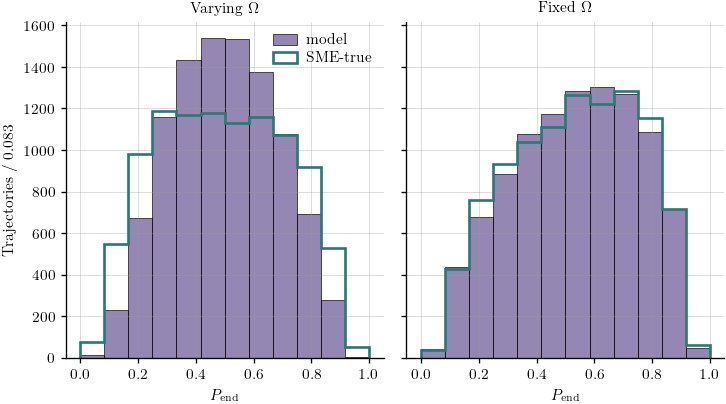

In [12]:
bin_width   = prob_edges[1] - prob_edges[0]
panel_specs = [('vary', r'Varying $\Omega$'), ('const', r'Fixed $\Omega$')]

fig, axes = plt.subplots(1, 2, sharey=True,
                         figsize=ps.figsize(ps.FULLWIDTH_IN, aspect=1.75))
for ax, (name, title) in zip(axes, panel_specs):
    cal = calibration[name]
    ax.hist(cal['p_pred'], bins=prob_edges, color=ps.PALETTE['purple'], alpha=0.65,
            edgecolor='black', label='model')
    ax.hist(cal['p_true'], bins=prob_edges, histtype='step', color=ps.PALETTE['teal'],
            lw=1.6, label='SME-true')
    ax.set_xlabel(r'$P_\text{end}$')
    ax.set_title(title)
axes[0].set_ylabel(rf'Trajectories / {bin_width:.3f}')
axes[0].legend(loc='best')

fig.tight_layout()
ps.save_fig(fig, 'calibration')

for name, _ in panel_specs:
    cal = calibration[name]
    brier_model    = ((cal['p_pred'] - cal['outcome']) ** 2).mean()
    brier_true     = ((cal['p_true'] - cal['outcome']) ** 2).mean()
    brier_baseline = ((cal['outcome'].mean() - cal['outcome']) ** 2).mean()
    print(f"[{name}] Brier  model={brier_model:.4f}   true-SME={brier_true:.4f} (floor)   "
          f"baseline={brier_baseline:.4f}   skill={1 - brier_model / brier_baseline:.3f}")

## Plot 5 — Physical validity of $\rho_\text{NN}$ ($\hat C_\text{mon}\propto\hat\sigma_z$)
The Kraus head ensures CPTP, so trace,
Hermiticity and positivity should hold to floating-point. Verified over all
$\hat\sigma_z$ trajectories from both the varying-$\Omega$ (top row) and
fixed-$\Omega$ (bottom row) datasets. Each panel shows the **worst case across
trajectories per time step** — $\max_n|\mathrm{Tr}\,\rho_\text{NN}-1|$,
$\max_n\max|\rho-\rho^\dagger|$ and $\min_n\lambda_\mathrm{min}(\rho)$

In [12]:
def validity_worst_case(cache):
    rho = cache['rho_nn'][cache['tasks'] == TASK_Z]
    rho00, rho11, rho01 = rho[..., 0, 0].real, rho[..., 1, 1].real, rho[..., 0, 1]
    discriminant = np.sqrt(np.maximum((rho00 - rho11) ** 2 + 4 * np.abs(rho01) ** 2, 0))
    trace_err = np.einsum('...ii->...', rho).real - 1.0
    herm_err  = np.abs(rho - rho.conj().transpose(0, 1, 3, 2)).max(axis=(-2, -1))
    lam_min   = 0.5 * (rho00 + rho11 - discriminant)
    return dict(
        n=rho.shape[0],
        max_abs_trace_error=np.abs(trace_err).max(axis=0),
        max_hermiticity_error=herm_err.max(axis=0),
        min_eigenvalue=lam_min.min(axis=0),
    )

validity = {name: validity_worst_case(cache) for name, cache in eval_cache.items()}

'figures/physical_validity.pdf'

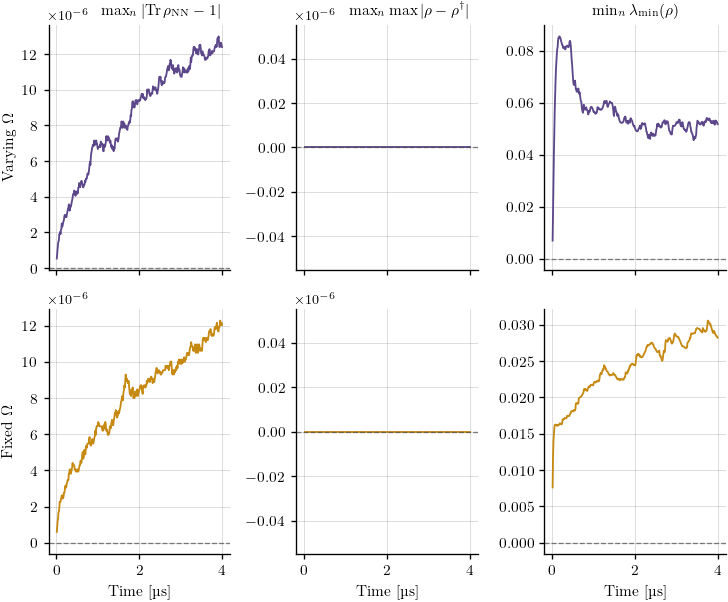

In [13]:
row_specs = [
    ('vary',  r'Varying $\Omega$', ps.PALETTE['purple']),
    ('const', r'Fixed $\Omega$',   ps.PALETTE['ochre']),
]
panels = [
    ('max_abs_trace_error',   1e-6, r'$\max_n|\mathrm{Tr}\,\rho_\text{NN} - 1|$'),
    ('max_hermiticity_error', 1e-6, r'$\max_n\max|\rho - \rho^\dagger|$'),
    ('min_eigenvalue',        1.0,  r'$\min_n\lambda_\mathrm{min}(\rho)$'),
]

fig, axes = plt.subplots(2, 3, sharex=True, figsize=ps.figsize(ps.FULLWIDTH_IN, aspect=1.2))

for row, (name, row_label, color) in enumerate(row_specs):
    v = validity[name]
    axes[row, 0].set_ylabel(row_label)
    for col, (key, scale, label) in enumerate(panels):
        ax = axes[row, col]
        y = (v[key] / scale).astype(np.float64)
        ax.plot(t_axis, y, color=color)
        ax.axhline(0, color=ps.PALETTE['gray'], ls='--', lw=0.8, alpha=0.7)
        if row == 0:
            # Shift title right when a scale-exponent annotation sits at the top-left
            # of the panel, otherwise the two collide.
            title_x = 0.62 if scale != 1.0 else 0.5
            ax.set_title(label, x=title_x)
        if row == len(row_specs) - 1:
            ax.set_xlabel(r'Time [µs]')
        if scale != 1.0:
            exponent = int(round(np.log10(scale)))
            ax.text(0.0, 1.02, rf'$\times 10^{{{exponent}}}$',
                    transform=ax.transAxes, ha='left', va='bottom', fontsize=8)

fig.align_ylabels(axes[:, 0])
fig.tight_layout()
ps.save_fig(fig, 'physical_validity')

## Plot 6 — Unconditional dynamics: ensemble-mean vs Lindblad
Averaging the conditional states over many measurement records recovers the
unconditional evolution. We compare $\overline{\rho_\text{NN}}$,
$\overline{\rho_\text{true}}$ and a `qutip` Lindblad reference. Each row
is one measurement-direction dataset (records monitored along $\hat\sigma_x$,
$\hat\sigma_y$ or $\hat\sigma_z$); each column is a computational-basis
density-matrix element $\rho_{00}$, $\mathrm{Re}\,\rho_{01}$,
$\mathrm{Im}\,\rho_{01}$ — the same convention as Plots 1 & 5. ($\eta$ drops out
unconditionally, so the reference depends only on $\kappa$ and $\gamma_d$.)

In [14]:
cache = eval_cache['const']

ensemble_rho = {}
for task_id in (TASK_X, TASK_Y, TASK_Z):
    in_basis = cache['tasks'] == task_id
    ensemble_rho[task_id] = dict(
        nn       = cache['rho_nn'][in_basis].mean(0),
        true     = cache['rho_true'][in_basis, 1:].mean(0),
        lindblad = lindblad_ref(task_id, OMEGA),
    )

'figures/ensemble_lindblad.pdf'

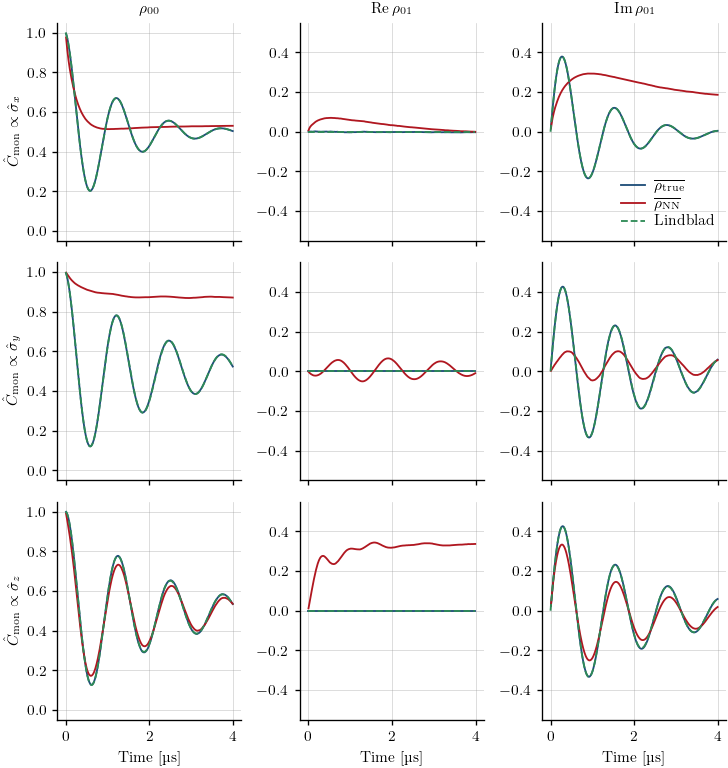

In [15]:
row_tasks = (TASK_X, TASK_Y, TASK_Z)

col_components = [
    (r'$\rho_{00}$',              lambda r: r[:, 0, 0].real, (-0.05, 1.05)),
    (r'$\mathrm{Re}\,\rho_{01}$', lambda r: r[:, 0, 1].real, (-0.55, 0.55)),
    (r'$\mathrm{Im}\,\rho_{01}$', lambda r: r[:, 0, 1].imag, (-0.55, 0.55)),
]
fig, axes = plt.subplots(3, 3, sharex=True, sharey='col',
                         figsize=ps.figsize(ps.FULLWIDTH_IN, aspect=0.95))

for row, task_id in enumerate(row_tasks):
    curves = ensemble_rho[task_id]
    axes[row, 0].set_ylabel(rf'$\hat C_\text{{mon}}\propto\hat\sigma_{TASK_BASIS_CHAR[task_id]}$')
    for col, (label, extract, ylim) in enumerate(col_components):
        ax = axes[row, col]
        ax.plot(t_axis, extract(curves['true']), color=ps.SEMANTIC['truth'], label=r'$\overline{\rho_\text{true}}$')
        ax.plot(t_axis, extract(curves['nn']),   color=ps.SEMANTIC['model'], label=r'$\overline{\rho_\text{NN}}$')
        ax.plot(times,  extract(curves['lindblad']), color=ps.SEMANTIC['fit'], ls='--', label='Lindblad')
        ax.set_ylim(ylim)
        if row == 0:
            ax.set_title(label)
        if row == 2:
            ax.set_xlabel(r'Time [µs]')
axes[0, -1].legend(loc='best')
fig.align_ylabels(axes[:, 0])
fig.tight_layout()
ps.save_fig(fig, 'ensemble_lindblad')

## Plot 7 — Per-trajectory $\rho$-elements in each measurement basis
One sample trajectory per basis from the const set. $\rho$ is kept in the
computational $\hat\sigma_z$ basis for all three sample trajectories — so the
panels are directly comparable across measurement directions, and to Plot 6.
Only $\rho_\text{true}$ and $\rho_\text{NN}$ are shown — one $2\times2$ component
grid per basis.

In [ ]:
cache = eval_cache['const']
sample_rng = np.random.default_rng(42)
# Keep rho in the computational (z) basis for every measurement direction
basis_samples = {}
for task_id in (TASK_X, TASK_Y, TASK_Z):
    traj_index    = int(sample_rng.choice(np.where(cache['tasks'] == task_id)[0]))
    rho_true_z    = cache['rho_true'][traj_index]
    rho_nn_z      = np.concatenate([rho0_np[None], cache['rho_nn'][traj_index]], axis=0)
    basis_samples[task_id] = dict(index=traj_index, rho_true=rho_true_z, rho_nn=rho_nn_z)

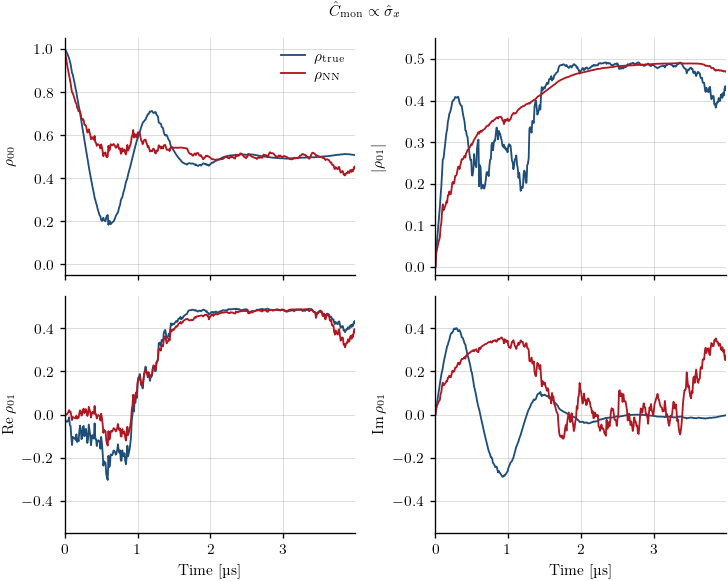

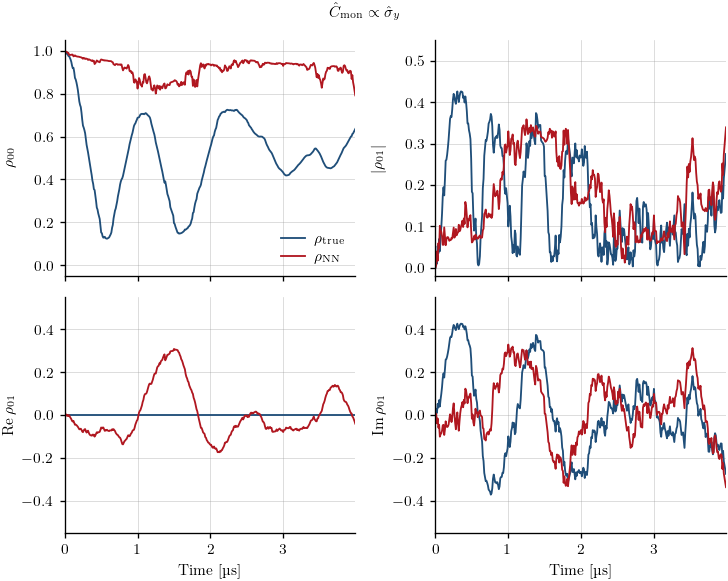

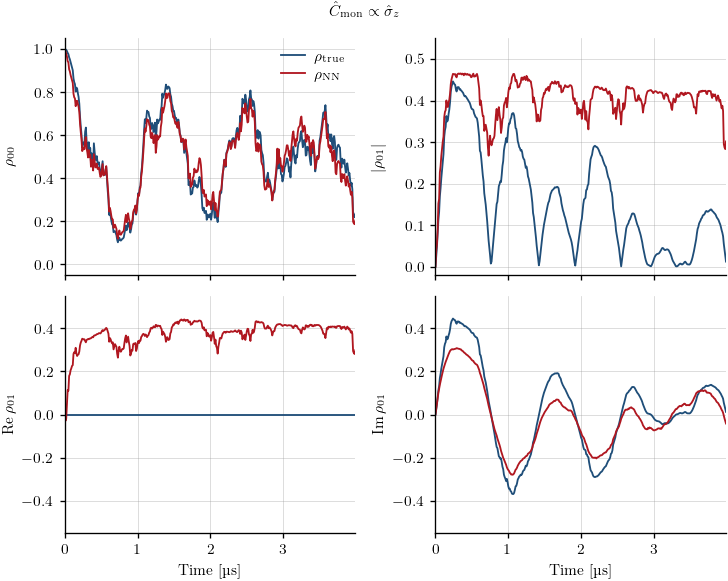

In [17]:
for task_id in (TASK_X, TASK_Y, TASK_Z):
    sample = basis_samples[task_id]
    fig, axes = plt.subplots(2, 2, sharex=True, figsize=ps.figsize(aspect=1.25))
    for ax, (label, extract, ylim) in zip(axes.flat, RHO_COMPONENTS):
        ax.plot(times, extract(sample['rho_true']), color=ps.SEMANTIC['truth'], label=r'$\rho_\text{true}$')
        ax.plot(times, extract(sample['rho_nn']),   color=ps.SEMANTIC['model'], label=r'$\rho_\text{NN}$')
        ax.set_ylabel(label)
        ax.set_ylim(ylim)
        ax.set_xlim(times[0], times[-1])
    for ax in axes[-1]:
        ax.set_xlabel(r'Time [µs]')
    axes[0, 0].legend(loc='best')
    fig.suptitle(rf'$\hat C_\text{{mon}}\propto\hat\sigma_{TASK_BASIS_CHAR[task_id]}$')

    fig.align_ylabels(axes)
    fig.tight_layout()
    ps.save_fig(fig, f'meas_basis_{TASK_BASIS_CHAR[task_id]}')